# Western Alps

We want to cover the rectangle Lausanne-Jouques-Sanremo-Zermatt
aka `5.6250 43.5804 7.7343 46.558`
or in bbox: 5.625, 43.581, 7.734, 46.558

That includes

⚠ This notebook only contains the merge part. It depends on the individual datasets. For details on each dataset and (possibly) direct download links, check [main README](../README.md)

eg
* `data/dtm_local/ignalps_dtm.tif` from Western-Alps-dwn-ign.ipynb
* 

## Strategy

1. Since each country uses its own projection, and because dtms are scattered over many files, we usually have to build a vrt. It's possible to go directly from vrt to slope, but in order to ease further development, I chose to generate a _*dtm.tif_ for each area. I keep Float32 as Float16 has up to 4 meter (im)precision, and compress carefully based on some [sample_tests](sample_tests/sample_tests.ipynb).
  **DTM computation is in the _Central-Alps-dwn-*.ipynb_ files**.
2. Generate `gdaldem slope` in the native projection, to get best precision
3. Reproject, resample and merge with `gdalwarp`.
4. Color with color-relief, converting to mbtiles at the same time.
5. For overviews, several options exist, for now I do **B**:
  * **A**: *best precision*: rerun step (3) with different `-tr`
  * **B**: *intermediate*: downsample slope model from step (3), with `-r q3`
  * **C**: *worst precision*: reuse (4), and downsample the image with `-r mode`

# Status

Done but this notebook is still trying to cach up on the steps manually performed elewhere eg Western-Alps.ipynb and src/merge_dem_fr_it.sh

⚠ You will need at least 30 GB disk space in there

In [1]:
%load_ext autoreload
%autoreload 2

import os
NBROOT = os.path.realpath(os.curdir)  # 'development'

In [2]:
# Preamble
import logging
logging.basicConfig(level=logging.DEBUG)
logging.getLogger('PIL').level = logging.INFO # PIL.PngImagePlugin

import os
from os.path import exists, join as pjoin, realpath
from pathlib import Path
from time import time

from IPython.display import Image

from src import bbox, gdal_slope_util as S, mbt_util as M

In [3]:
%cd $NBROOT/data
!mkdir -p slope_local
!mkdir -p alpsc

/home/eoubrayrie/mapproj/eslope/development/data


In [4]:
ESLO_CX = 'alps/AlpsW_eslo'
SLOP_CX = 'alps/AlpsW_slope'
BB = bbox.bbwalps
BBB = BB.snap_to_xyz(z=10)
print(BBB)

5.625000 43.580391 7.734375 46.558860


### Merge slopes

In [ ]:
# Put most precise last, for overlap
# reminder: 5.625000 43.580391 7.734375 46.558860
wsrc = ' '.join((
        'slope_local/ignalps6_slope.tif',    # 5/40m
        'slope_local/piemont_slope.tif',     # 5m
        'slope_local/aoste_slope.tif',       # 2m
        'slope_local/chw_slope.tif',         # 2m
        'dtm_local/ignhdAlpsW_1m5_slope.tif', # 1.5m
))
        # 'slope_local/ignalex_slope.tif',                # .5m
        # 'slope_local/ecrins_1m5_slope.tif',             # 1.5m
        # 'slope_local/meije_1m5_slope.tif',
        # 'slope_local/mer-de-glace_1m5_slope.tif',

# assert all files exist
for f in wsrc.split():
    assert os.path.exists(f), f+' does not exist'

In [6]:
for z in (15, 16):
    S.warp_slopes(src=wsrc, dest=f'{SLOP_CX}_z{z}.tif', z=z, extent=BBB)
# Creating output file that is 49152P x 98304L.
# z15: 6 minutes, 1.7GB
# Creating output file that is 98304P x 196608L.
# z16: 8 minutes, 3.8GB


      gdalwarp -ot Byte \
        -co COMPRESS=ZSTD -co PREDICTOR=2 -co ZSTD_LEVEL=3 -co TILED=YES -co blockXsize=1024 -co blockYsize=1024 -co BIGTIFF=YES -co SPARSE_OK=TRUE -co NUM_THREADS=ALL_CPUS -multi -wo NUM_THREADS=ALL_CPUS -overwrite  \
        -t_srs EPSG:3857 -tr 4.777314267823516 -4.777314267823516 -r q3 \
        -te_srs WGS84 -te 5.625000 43.580391 7.734375 46.558860  -dstnodata 255  \
        slope_local/ignalps6_slope.tif slope_local/piemont_slope.tif slope_local/aoste_slope.tif slope_local/chw_slope.tif dtm_local/ignhdAlpsW_1m5_slope.tif alps/AlpsW_slope_z15.tif
Creating output file that is 49152P x 98304L.
Processing slope_local/ignalps6_slope.tif [1/5] : 0Using internal nodata values (e.g. -9999) for image slope_local/ignalps6_slope.tif.
...10...20...30...40...50...60...70...80...90..Processing slope_local/piemont_slope.tif [2/5] : Using internal nodata values (e.g. -9999) for image slope_local/piemont_slope.tif.
Processing slope_local/aoste_slope.tif [3/5] : Using in

In [7]:
for z in 14, 12:
    S.make_ovr(src=f'{SLOP_CX}_z{z+2}.tif', dest=f'{SLOP_CX}_z{z}.tif', r='q3', z=z, reuse=True)
# 1 min / 500MB / 40 MB (6144P x 12288L)

Reuse alps/AlpsW_slope_z14.tif
Reuse alps/AlpsW_slope_z12.tif


gdalwarp -overwrite -tr 300 -300 alps/AlpsW_slope_z12.tif /tmp/tiny.tif
Creating output file that is 783P x 1565L.
Processing alps/AlpsW_slope_z12.tif [1/1] : 0Using internal nodata values (e.g. 255) for image alps/AlpsW_slope_z12.tif.
Copying nodata values from source alps/AlpsW_slope_z12.tif to destination /tmp/tiny.tif.
...10...20...30...40...50...60...70...80...90...100 - done.
gdaldem color-relief /tmp/tiny_slope.tif /home/eoubrayrie/mapproj/eslope/development/data/gdaldem-slope-eslo13bnear.clr /tmp/tiny_eslo13bnear.png -nearest_color_entry
0...10...20...30...40...50...60...70...80...90...100 - done.


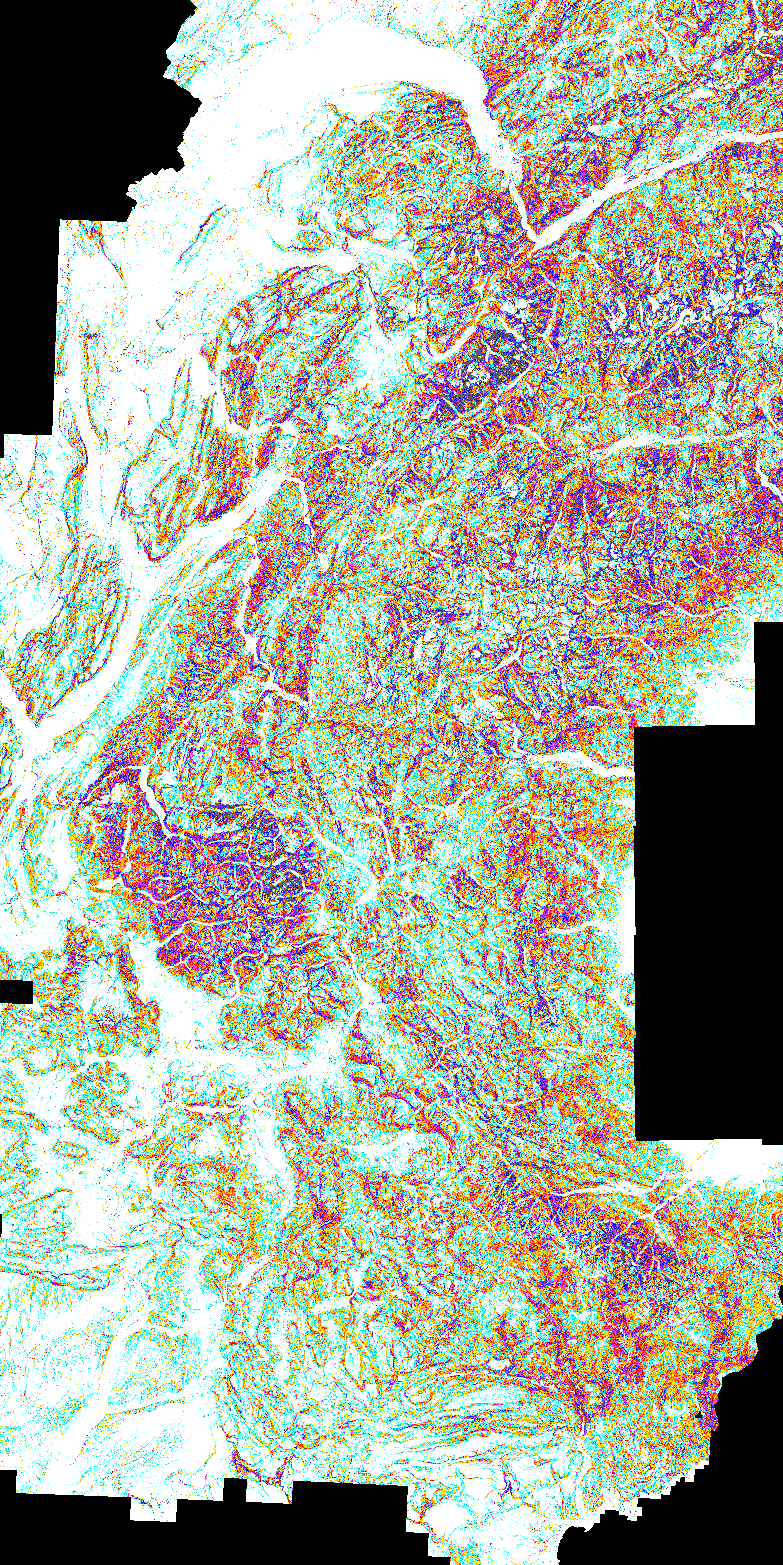

In [8]:
Image(S.eslo_tiny(SLOP_CX + '_z12.tif', res=300)) #S.resolutions[11]))

In [9]:
files=[]
R_USP = 'bilinear'
for z, cname in {
        16: 'eslo13bnear',
        15: 'eslo13bnear',
        14: 'eslo4near',
        13: 'eslo4near',
    }.items():
        chkpoint = time()
        slope = f'{SLOP_CX}_z{z}.tif' if z < 15 else f'{SLOP_CX}_z{z}.tif'
        zsrc = {16:16, 15: 14, 14: 12, 13:12}[z]  # would need changes to select target res
        if zsrc != z:
            upsampled = f'{SLOP_CX}_z{zsrc}_up_z{z}.tif'
            S.make_ovr(src=f'{SLOP_CX}_z{zsrc}.tif', dest=upsampled, z=z, r=R_USP, reuse=False)
            slope = upsampled
        # to_merge = S.slope_mbt(cname, z=z, src=f'{SLOP_CX}_z{zsrc}.tif', dest=f'{prefix}{cname}_z{z}.mbtiles',
        #                        options=f'-co ZOOM_LEVEL={z} -co RESAMPLING=nearest', reuse=False)
        to_merge = S.slope_mbt(cname, z=z, src=slope, dest=f'alps/AlpsW_{cname}_z{z}.mbtiles', reuse=False)
        files.append(os.path.expanduser(to_merge))
        print(f'Zoom {z} completed in {round(time()-chkpoint,1)} seconds')
S.mbt_merge(*files, dest=f'{ESLO_CX}.mbtiles')

# Creating output file that is 49152P x 98304L.
# 13+... = 23 min

sed 's/nv \+0 \+0 \+0/nv  255 255 255/g' '/home/eoubrayrie/mapproj/eslope/development/data/gdaldem-slope-eslo13bnear.clr' 
\
      gdaldem color-relief alps/AlpsW_slope_z16.tif /tmp/gdaldem-slope-eslo13bnear.clr alps/AlpsW_eslo13bnear_z16.mbtiles \
          -nearest_color_entry -co TILE_FORMAT=png8 
0...10...20...30...40...50...60...70...80...90...100 - done.
Zoom 16 completed in 1392.7 seconds
      gdalwarp -r bilinear -tr 4.777314267823516 -4.777314267823516 \
        -co COMPRESS=ZSTD -co PREDICTOR=2 -co ZSTD_LEVEL=3 -co TILED=YES -co blockXsize=1024 -co blockYsize=1024 -co BIGTIFF=YES -co SPARSE_OK=TRUE -co NUM_THREADS=ALL_CPUS -multi -wo NUM_THREADS=ALL_CPUS -overwrite   \
        alps/AlpsW_slope_z14.tif alps/AlpsW_slope_z14_up_z15.tif
Creating output file that is 49152P x 98304L.
Processing alps/AlpsW_slope_z14.tif [1/1] : 0Using internal nodata values (e.g. 255) for image alps/AlpsW_slope_z14.tif.
Copying nodata values from source alps/AlpsW_slope_z14.tif to destination alps/

In [ ]:
# S.warp_slopes(src=wsrc, dest=SLOP_CX + '_z16.vrt', z=16, extent=bbox.bbcalps)

### Add overviews

In [35]:
M.real_bounds('alpsc/esloAlpsW.mbtiles', log=print)

real bounds  9 [5.63, 43.58, 7.73, 46.56] 264 325 266 330
real bounds  13 [5.63, 43.58, 7.73, 46.56] 4224 5200 4271 5295
real bounds  14 [5.63, 43.58, 7.73, 46.56] 8448 10400 8543 10591
real bounds  15 [5.63, 43.58, 7.73, 46.56] 16896 20800 17087 21183
real bounds  16 [5.63, 43.58, 7.73, 46.56] 33792 41600 34175 42367


(9,
 16,
 LngLatBbox(west=5.625000000000014, south=43.580390855607845, east=7.73437500000001, north=46.55886030311717))

In [30]:
M.mbt_info('alps0/white9.mbtiles')

'zoom = 9 9 ; n = 18 * 1 kb/tile ; name = white9 ; format = png ; bounds = 5.62499878087688998,43.5797725532024245,7.73437378087689087,46.3159946727953837'

In [40]:

# S.slope_mbt_5_zooms('alps/AlpsC_slopes.tif', reuse=True)  # now done above
M.mbt_merge('alps0/white9.mbtiles', dest=f'{ESLO_CX}.mbtiles')
M.mbt_merge('alps0/white9.mbtiles', dest=f'alps/AlpsW_eslo.mbtiles')
# M.mbt_merge('alps/white9.mbtiles', dest='alps/esloAlpsW.mbtiles')

<< alps0/white9 : zoom = 9 9 ; n = 18 * 1 kb/tile ; name = white9 ; format = png ; bounds = 5.62499878087688998,43.5797725532024245,7.73437378087689087,46.3159946727953837
>> alpsc/AlpsW_eslo : zoom = 9 9 ; n = 18 ; bounds = 5.625,43.58039,7.73438,46.55886 ; center = 6.67969,45.06963,9 ; format = png ; name = alpsc/AlpsW_eslo
Meta update {'bounds': '5.625,43.58039,7.73438,46.55886',
 'center': '6.67969,45.06963,9',
 'maxzoom': 9,
 'minzoom': 9,
 'type': 'baselayer'}
<< alps0/white9 : zoom = 9 9 ; n = 18 * 1 kb/tile ; name = white9 ; format = png ; bounds = 5.62499878087688998,43.5797725532024245,7.73437378087689087,46.3159946727953837
>> alps/AlpsW_eslo : zoom = 9 16 ; n = 391698 ; bounds = 5.625,43.58039,7.73438,46.55886 ; center = 6.67969,45.06963,13 ; format = png ; name = eSlope Alps Aix<->Zermatt
Meta update {'bounds': '5.625,43.58039,7.73438,46.55886',
 'center': '6.67969,45.06963,9',
 'maxzoom': 16,
 'minzoom': 9,
 'type': 'baselayer'}


In [5]:
M.update_mbt_meta('alps/AlpsW_eslo.mbtiles', name='eSlope Alps Aix<->Zermatt ''26', desc='https://github.com/eslopemap/eslope', zmin=13, zmax=16, format='png')

In [42]:
M.real_bounds('alps/AlpsW_eslo.mbtiles', log=print)

real bounds  9 [5.63, 43.58, 7.73, 46.56] 264 325 266 330
real bounds  13 [5.63, 43.58, 7.73, 46.56] 4224 5200 4271 5295
real bounds  14 [5.63, 43.58, 7.73, 46.56] 8448 10400 8543 10591
real bounds  15 [5.63, 43.58, 7.73, 46.56] 16896 20800 17087 21183
real bounds  16 [5.63, 43.58, 7.73, 46.56] 33792 41600 34175 42367


(9,
 16,
 LngLatBbox(west=5.625000000000014, south=43.580390855607845, east=7.73437500000001, north=46.55886030311717))

In [9]:
# merge west an center for the pmtiles
M.mbt_merge(ESLO_CX+'.mbtiles', 'alps/esloAlpsW.mbtiles', dest='alpsc/AlpsWC_eslo.mbtiles')

cp alpsc/AlpsC_eslo.mbtiles alpsc/AlpsWC_eslo.mbtiles
<<>> alpsc/AlpsC_eslo : zoom = 12 16 ; n = 526261 ; format = png ; bounds = 7.73399999999999999,45.5829616352129463,11.9530933227539062,47.5169999999999959
<< alps/esloAlpsW : zoom = 9 16 ; n = 391698 ; format = png ; bounds = 5.62499878087688998,43.5797725532024245,7.73437500000000089,46.558000000000014
>> alpsc/AlpsWC_eslo : zoom = 9 16 ; n = 917475 ; format = png ; bounds = 5.62499878087688998,43.5797725532024245,11.9530933227539062,47.5169999999999959
alpsc/AlpsWC_eslo Merge of the following files:
* alpsc/AlpsC_eslo : Merge of the following files:
* AlpsC_eslo13near_z16 : AlpsC_eslo13near_z16
* AlpsC_eslo13near_z15 : AlpsC_eslo13near_z15
* AlpsC_eslo4near_z14 : AlpsC_eslo4near_z14
* AlpsC_eslo4near_z13 : AlpsC_eslo4near_z13
* AlpsC_eslo2_z12 : AlpsC_eslo2_z12

* alps/esloAlpsW : Merge of the following files:
* alps/esloAlpsW : Merge of the following files:
* alps/esloAlpsW : Merge of the following files:
* eslo13near-z16 : eslo

In [26]:
M.mbt_info('alps/AlpsW_eslo.mbtiles')
# 'zoom = 13 16 ; n = 391680 * 6 kb/tile ; bounds = 5.625,43.58039,7.73438,46.55886 ; center = 6.67969,45.06963,13

'zoom = 13 16 ; n = 391680 * 6 kb/tile ; bounds = 5.625,43.58039,7.73438,46.55886 ; center = 6.67969,45.06963,13 ; format = png ; name = alpsc/AlpsW_eslo'

In [27]:
M.update_mbt_meta('alps/AlpsW_eslo.mbtiles', name='eSlope Alps Aix<->Zermatt', desc='https://github.com/eslopemap/eslope', zmin=13, zmax=16, format='png')

In [46]:
# M.set_bounds('alpsc/AlpsWC_eslo.mbtiles',*M.get_bounds('alpsc/AlpsWC_eslo.mbtiles'))

In [51]:
# !~/code/UPSTREAM/pmtiles/python/bin/pmtiles-convert 'alpsc/AlpsWC_eslo.mbtiles' 'alpsc/AlpsWC_eslo.pmtiles'

Num tiles: 917475
Num unique tiles: 805968
Num leaves: 7


In [58]:
import sys
sys.path.insert(0, os.path.expanduser('~/code/UPSTREAM/pmtiles/python/'))
# pip install pmtiles

from pmtiles import convert

In [63]:
convert.mbtiles_to_pmtiles('alps/AlpsW_eslo.mbtiles', 'alpsc/AlpsW_eslo.pmtiles', None)

Num tiles: 917475
Num unique tiles: 805968
Num leaves: 10880


In [64]:
!aws s3 cp  --acl public-read  alps/AlpsW_eslo.pmtiles  s3://maps/

upload: alpsc/AlpsWC_eslo.pmtiles to s3://maps/AlpsWC_eslo.pmtiles
